In [1]:
import pandas as pd

data_path = "../data/mexico-real-estate-combined-clean.csv"

df = pd.read_csv(data_path)

print(df.shape)

(1736, 6)


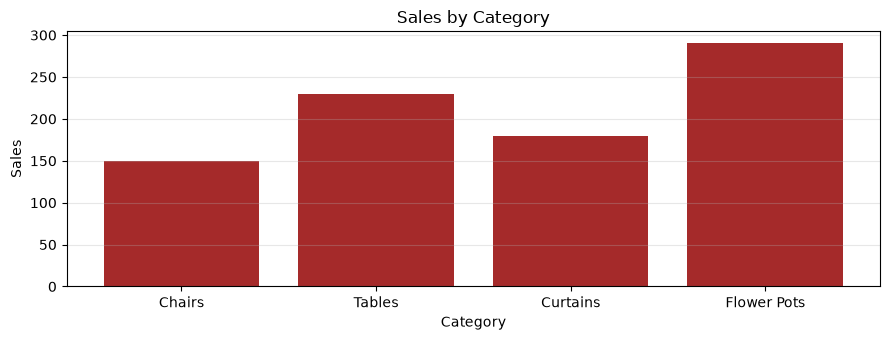

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

data = {
    "category": ["Chairs", "Tables", "Curtains", "Flower Pots"],
    "sales": [150, 230, 180,290],
    "profits": [45, 82, 55, 95]
}
fig,ax = plt.subplots(figsize=(9, 3.5))
ax.bar(data["category"], data["sales"], color="brown")
ax.set_xlabel("Category")
ax.set_ylabel("Sales")
ax.set_title("Sales by Category")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


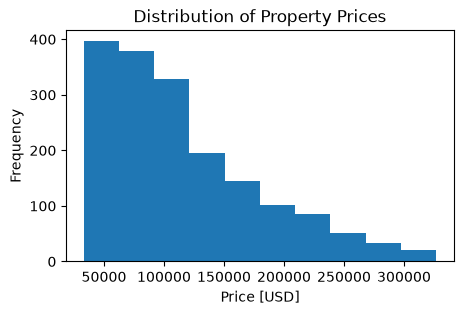

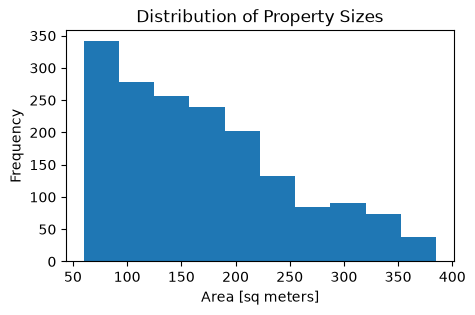

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

data_path = "../data/mexico-real-estate-combined-clean.csv"

df = pd.read_csv(data_path)

fig, ax = plt.subplots(figsize=(5, 3))

ax.hist(df["price_usd"])

ax.set_xlabel("Price [USD]")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Property Prices")
plt.show()

fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(df["area_m2"])
ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Property Sizes")
plt.show()

/tmp/ipykernel_2321/3766405751.py:16: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data_by_type,tick_labels=prop_types, vert=False)


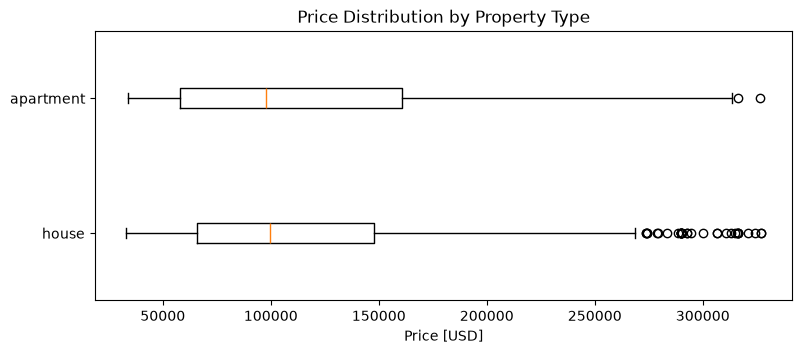

In [4]:
# boxplot

import matplotlib.pyplot as plt
import pandas as pd

data_path = "../data/mexico-real-estate-combined-clean.csv"

df = pd.read_csv(data_path)

prop_types = df["property_type"].unique()

data_by_type = [df[df["property_type"]==label]["price_usd"] for label in prop_types]

fig, ax = plt.subplots(figsize=(9,3.5))

ax.boxplot(data_by_type,tick_labels=prop_types, vert=False)

ax.set_title("Price Distribution by Property Type")
ax.set_xlabel("Price [USD]")


plt.show() 


Interpreting houses versus apartments

The source suggests that houses and apartments may have similar total-price medians.

If your actual boxplot shows that, you can say:

The median listed prices of houses and apartments are relatively close in this dataset.

But do not immediately conclude:

"Property type does not matter."

Why not?

Because total price is only one way to compare properties.

A house might be:

150 m²

while an apartment might be:

70 m²

Even if both cost approximately:

$100,000

their prices per square meter are very different.

For example:

House = 100,000/ 150  ≈667 USD/m2

Apartment= 100,000/70≈1,429 USD/m2

The apartment has a much higher price per square meter.

So two property types can have similar total prices but very different unit prices.

This is why we will later introduces:

price_per_m2 = area_m2 / price_usd
	​


/tmp/ipykernel_2321/768631122.py:22: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data_by_state, tick_labels=selected_states, vert=False)


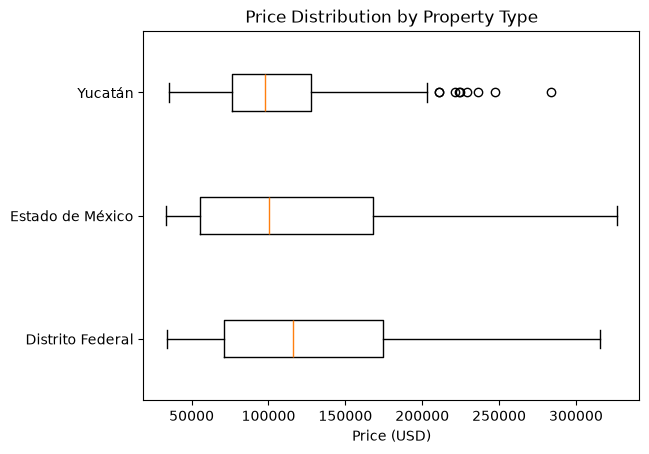

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

data_path = "../data/mexico-real-estate-combined-clean.csv"

df = pd.read_csv(data_path)

# 1. Define your selected states
selected_states = (
    df["state"]
    .value_counts()
    .head(3)
    .index.tolist()
)
# 2. Prepare the data
data_by_state = [df[df["state"] == state]["price_usd"] for state in selected_states]

# 3. Plot
fig, ax = plt.subplots()

# FIX: Use 'tick_labels' instead of 'labels'
ax.boxplot(data_by_state, tick_labels=selected_states, vert=False)

ax.set_title("Price Distribution by Property Type")
ax.set_xlabel("Price (USD)")
plt.show()

Location matters

Two properties with the same square footage ... would likely sell at very different prices.

But be careful.

The state boxplot alone doesn't actually demonstrate that two equal-sized properties have different prices.

Why?

Because the boxplot only contains:

state
   ↓
price

It doesn't control for:

area_m2

For example, perhaps Distrito Federal has more large properties in the dataset.

Then its higher prices could partly reflect property size, rather than location itself.

This is exactly why the next stages matter.

We're eventually going to investigate:

area ───────→ price
   \
    \
     state ──→ price

The research question is not simply:

"Are prices different across states?"

It's:

Are property prices more influenced by property size or location?

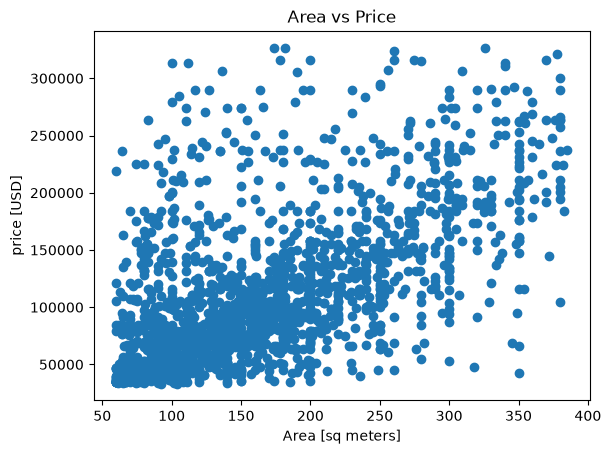

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

data_path = "../data/mexico-real-estate-combined-clean.csv"

df = pd.read_csv(data_path)

fig, ax = plt.subplots()

ax.scatter(x=df["area_m2"], y=df["price_usd"])

ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("price [USD]")
ax.set_title("Area vs Price")
plt.show()


Now we arrive at the third visualization.

A scatterplot is:

Numerical vs Numerical

For our project:

area_m2 → price_usd

Both variables are numerical.

What problem does a scatterplot solve?

The central question is:

"How are two numerical variables related?"

For example:

Do larger properties tend to have higher prices?

We put:

x = area_m2
y = price_usd

and every property becomes one point.

original:, 1736 rows
original:, 1497 rows
removed:, 239 rows


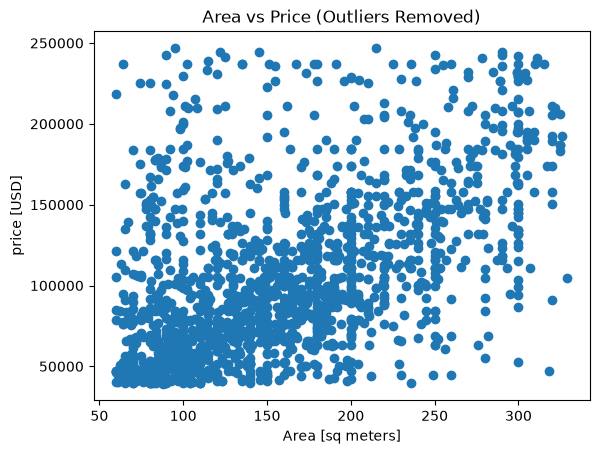

In [1]:
## Handling Outliers: Quantile-Based Filtering

import matplotlib.pyplot as plt
import pandas as pd

data_path = "../data/mexico-real-estate-combined-clean.csv"

df = pd.read_csv(data_path)

lower_cut = 0.05
upper_cut = 0.95

df_cleaned = (df[
    (df["price_usd"] > df["price_usd"].quantile(lower_cut))&
    (df["price_usd"] < df["price_usd"].quantile(upper_cut))&
    (df["area_m2"] < df["area_m2"].quantile(upper_cut))
])

fig, ax = plt.subplots()

print(f"original:, {len(df)} rows")
print(f"original:, {len(df_cleaned)} rows")
print(f"removed:, {len(df) - len(df_cleaned)} rows")

ax.scatter( df_cleaned["area_m2"], df_cleaned["price_usd"])
ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("price [USD]")
ax.set_title("Area vs Price (Outliers Removed)")
plt.show()


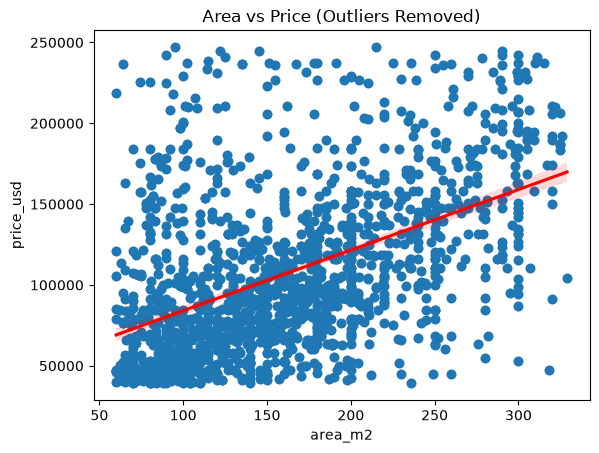

In [3]:
## Handling Outliers: Quantile-Based Filtering

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

data_path = "../data/mexico-real-estate-combined-clean.csv"

df = pd.read_csv(data_path)

lower_cut = 0.05
upper_cut = 0.95

df_cleaned = (df[
    (df["price_usd"] > df["price_usd"].quantile(lower_cut))&
    (df["price_usd"] < df["price_usd"].quantile(upper_cut))&
    (df["area_m2"] < df["area_m2"].quantile(upper_cut))
])

fig, ax = plt.subplots()

ax.scatter( df_cleaned["area_m2"], df_cleaned["price_usd"])
ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("price [USD]")
ax.set_title("Area vs Price (Outliers Removed)")
sns.regplot(
    data=df_cleaned,
    x="area_m2",
    y="price_usd",
    line_kws={"color":"red"},
    ax=ax
)
plt.show()
